# Práctica 6: Feature Scaling & Anti-Leakage Pipeline - Ames Housing

UT2: Calidad & Ética — Práctica Exploratoria



## Parte 1: Setup del entorno

In [1]:
# === SETUP DEL ENTORNO ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("Todas las librerías importadas correctamente")


Todas las librerías importadas correctamente


In [2]:
# Configurar visualizaciones
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("Configuración de visualizaciones lista!")


Configuración de visualizaciones lista!


## Paso 2: Cargar el Dataset Ames Housing

**Nota sobre VS Code / notebook local:** el `!curl ... kaggle.com/api/v1/datasets/download/...`
de la guía suele fallar sin autenticación. Dos opciones:

1. **Kaggle API con credenciales** (recomendado si ya usaste Kaggle antes): colocá tu
   `kaggle.json` en `~/.kaggle/kaggle.json` y corré la celda de abajo.
2. **Descarga manual**: bajá el zip desde
   https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset
   y colocá `AmesHousing.csv` en esta misma carpeta del proyecto.


In [3]:
# === CARGAR DATASET AMES HOUSING ===

# Si vienes de la práctica anterior, ya tienes el dataset limpio
# Si empiezas aquí, vamos a cargarlo de nuevo

# 1. Cargar dataset
!curl -L -o ames-housing-dataset.zip https://www.kaggle.com/api/v1/datasets/download/shashanknecrothapa/ames-housing-dataset
!unzip -o ames-housing-dataset.zip
df_raw = pd.read_csv('AmesHousing.csv')

print(f"Dataset Ames Housing cargado: {df_raw.shape}")
print("🏠 ¡Ahora vas a explorar las escalas en datos REALES!")

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
  0      0   0      0   0      0      0      0                              0
100 184.6k 100 184.6k   0      0 116.3k      0   00:01   00:01              0
Archive:  ames-housing-dataset.zip
  inflating: AmesHousing.csv         
Dataset Ames Housing cargado: (2930, 82)
🏠 ¡Ahora vas a explorar las escalas en datos REALES!


**Respuesta:**

1. ¿Cuáles son las 5 columnas numéricas con las escalas más diferentes?
2. ¿Hay outliers evidentes que podrían afectar el escalado?
3. ¿Qué variable será nuestro target para predicción?


In [5]:
# === EXPLORACIÓN INICIAL ===

print("=== INFORMACIÓN GENERAL DEL DATASET ===")
print(f"Dimensiones: {df_raw.shape}")
print(f"\nTipos de datos:")
print(df_raw.dtypes.value_counts())

numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n Columnas numéricas encontradas: {len(numeric_cols)}")

print("\n TU ANÁLISIS: Examina las escalas")
print("Estadísticas de las primeras 10 columnas numéricas:")
print(df_raw[numeric_cols[:10]].describe())

print("\n PREGUNTA PARA TI:")
print("Mira los valores de 'min' y 'max' arriba.")
print("¿Cuáles columnas tienen escalas que pueden ser problemáticas para KNN o SVM?")


=== INFORMACIÓN GENERAL DEL DATASET ===
Dimensiones: (2930, 82)

Tipos de datos:
str        43
int64      28
float64    11
Name: count, dtype: int64

 Columnas numéricas encontradas: 39

 TU ANÁLISIS: Examina las escalas
Estadísticas de las primeras 10 columnas numéricas:
            Order           PID  MS SubClass  Lot Frontage       Lot Area  \
count  2930.00000  2.930000e+03  2930.000000   2440.000000    2930.000000   
mean   1465.50000  7.144645e+08    57.387372     69.224590   10147.921843   
std     845.96247  1.887308e+08    42.638025     23.365335    7880.017759   
min       1.00000  5.263011e+08    20.000000     21.000000    1300.000000   
25%     733.25000  5.284770e+08    20.000000     58.000000    7440.250000   
50%    1465.50000  5.354536e+08    50.000000     68.000000    9436.500000   
75%    2197.75000  9.071811e+08    70.000000     80.000000   11555.250000   
max    2930.00000  1.007100e+09   190.000000    313.000000  215245.000000   

       Overall Qual  Overall Cond

**Respuesta:**
- Buscá columnas donde max/min > 1000 (escalas muy diferentes)
- ¿`Lot Area` vs `Year Built` vs `SalePrice` están en escalas similares?
- ¿Hay alguna columna que claramente va a "gritar más fuerte"?

## Paso 3: Identificar Variables Problemáticas

**Misión:** investigar y seleccionar columnas con escalas problemáticas.

,Columna,Min,Max,Rango,Ratio_max_min_positivo
1,Lot Area,1300.0,215245.0,213945.0,165.573077
0,SalePrice,12789.0,755000.0,742211.0,59.035108
2,Gr Liv Area,334.0,5642.0,5308.0,16.892216
3,1st Flr SF,334.0,5095.0,4761.0,15.254491
4,Garage Area,0.0,1488.0,1488.0,14.880000
5,Year Built,1872.0,2010.0,138.0,1.073718


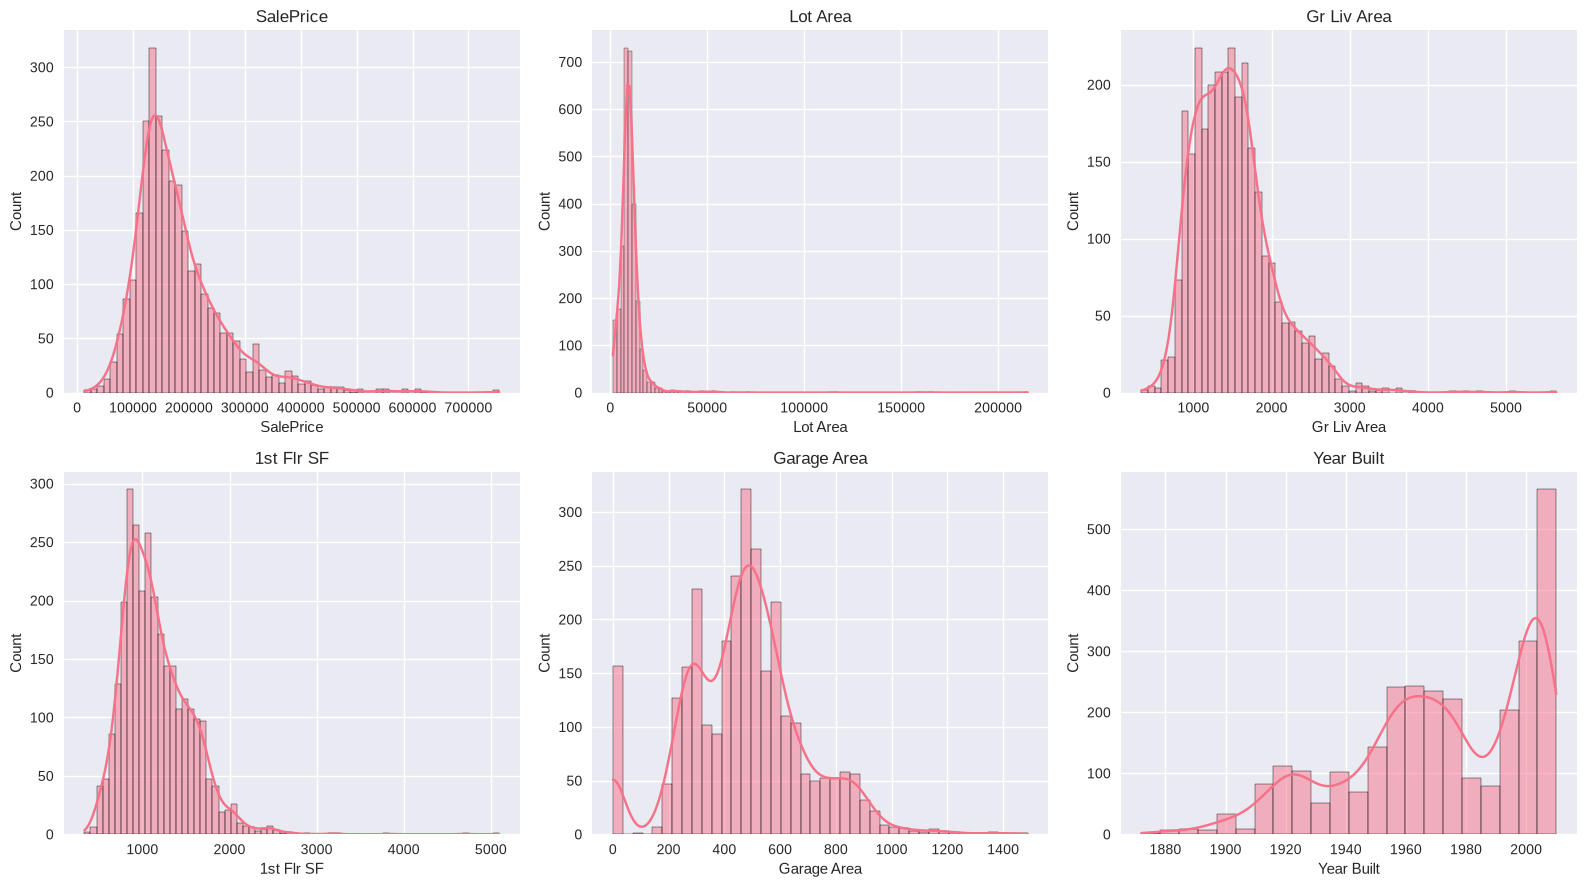

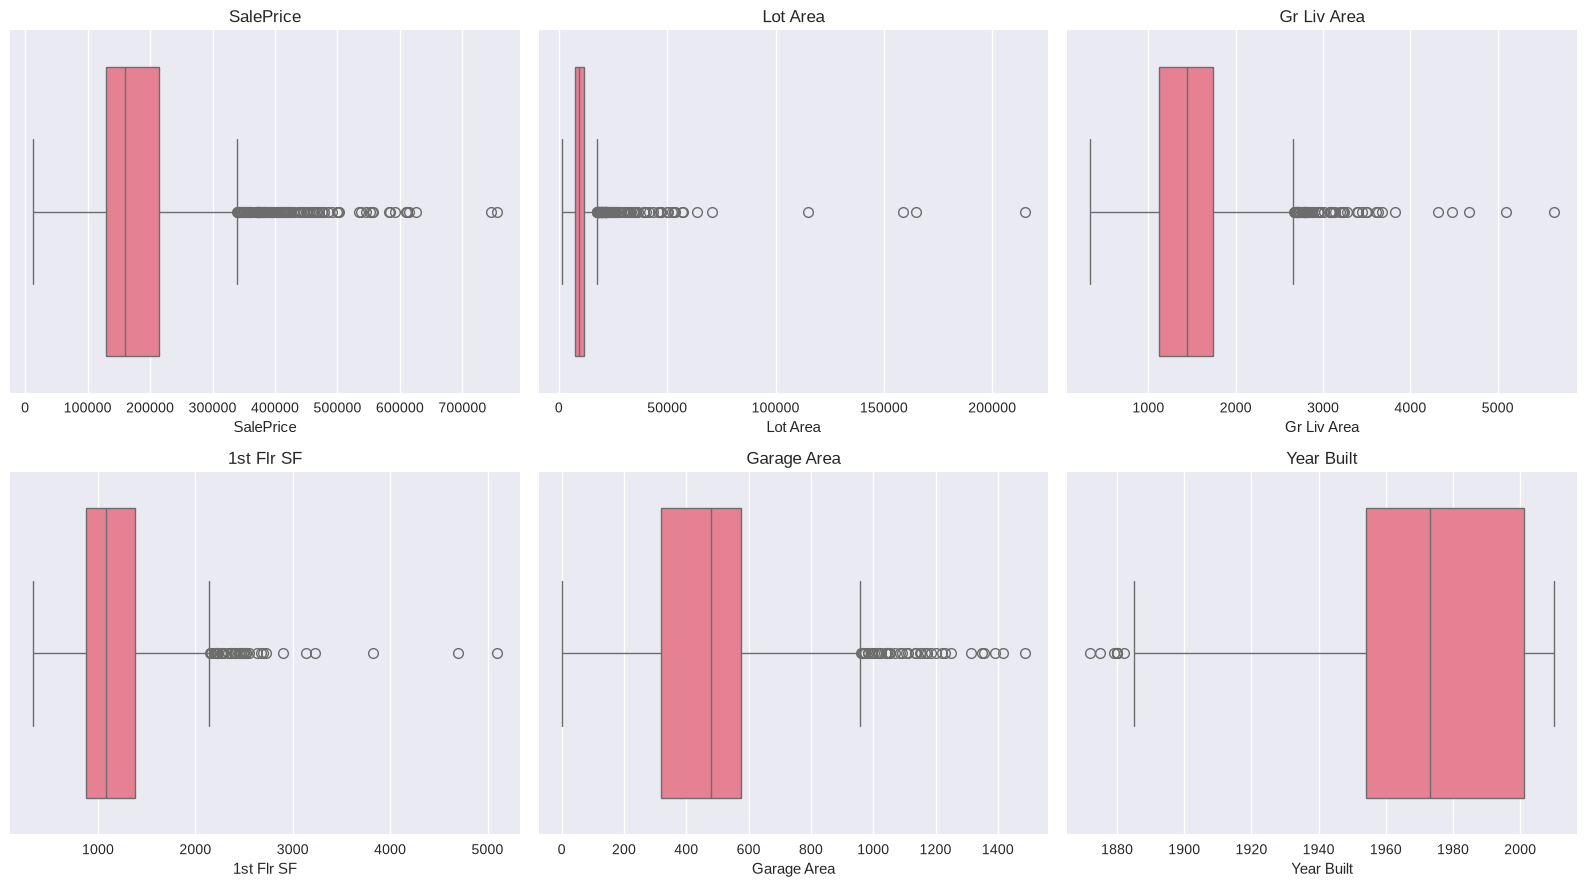

 MIS HALLAZGOS:
Columna más problemática por ratio: Lot Area
Ratio más alto: 165.57
¿Por qué es problemático?: porque las magnitudes son muy diferentes entre variables;
en modelos sensibles a distancia, como KNN o SVM, una variable de gran escala puede dominar a las demás.


In [6]:
# === TU INVESTIGACIÓN DE ESCALAS ===

import os
os.makedirs('results', exist_ok=True)

# Selección de variables numéricas con escalas y comportamientos distintos
selected_features = [
    'SalePrice', 'Lot Area', 'Gr Liv Area',
    '1st Flr SF', 'Garage Area', 'Year Built'
]

# Analizar escala: min, max, rango y ratio max/min
scale_analysis = []
for col in selected_features:
    s = df_raw[col].dropna()
    min_v = s.min()
    max_v = s.max()
    rango = max_v - min_v
    # Si min=0, usamos max / menor valor positivo para evitar división por cero
    positivos = s[s > 0]
    min_pos = positivos.min() if len(positivos) else np.nan
    ratio = max_v / min_pos if pd.notna(min_pos) and min_pos != 0 else np.nan
    scale_analysis.append([col, min_v, max_v, rango, ratio])

scale_df = pd.DataFrame(
    scale_analysis,
    columns=['Columna', 'Min', 'Max', 'Rango', 'Ratio_max_min_positivo']
).sort_values('Ratio_max_min_positivo', ascending=False)

display(scale_df)

# Visualizaciones
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), selected_features):
    sns.histplot(df_raw[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('results/histogramas_escalas.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), selected_features):
    sns.boxplot(x=df_raw[col].dropna(), ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('results/boxplots_escalas.png', dpi=150, bbox_inches='tight')
plt.show()

problematic = scale_df.iloc[0]
print(' MIS HALLAZGOS:')
print(f"Columna más problemática por ratio: {problematic['Columna']}")
print(f"Ratio más alto: {problematic['Ratio_max_min_positivo']:.2f}")
print('¿Por qué es problemático?: porque las magnitudes son muy diferentes entre variables;')
print('en modelos sensibles a distancia, como KNN o SVM, una variable de gran escala puede dominar a las demás.')


**Análisis**

La tabla se genera automáticamente en la celda anterior. Las variables como `SalePrice` y `Lot Area` trabajan con magnitudes mucho mayores que `Year Built` o `Garage Area`. Esto puede ser problemático en modelos basados en distancias porque las variables de mayor magnitud pueden dominar el cálculo aun cuando no sean las más importantes.


## Paso 4: Preparar Datos para Experimentar con Scalers

1. Definir target y features
2. Limpiar datos (NaN, inconsistencias)
3. Split ANTES de escalar (crítico para evitar leakage)
4. Verificar que el problema de escalas persiste

In [7]:
# === PREPARACIÓN DE DATOS ===

# Target y features
target_col = 'SalePrice'
feature_cols = ['Lot Area', 'Gr Liv Area', '1st Flr SF', 'Garage Area', 'Year Built', 'Overall Qual']

# Limpieza básica: conservar las columnas necesarias, convertir a numérico e imputar con mediana
model_df = df_raw[feature_cols + [target_col]].copy()
for col in model_df.columns:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')
    model_df[col] = model_df[col].fillna(model_df[col].median())

X = model_df[feature_cols].copy()
y = model_df[target_col].copy()

# Split ANTES de cualquier escalado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Verificar diferencias de escala en train
train_ranges = pd.DataFrame({
    'min': X_train.min(),
    'max': X_train.max(),
    'rango': X_train.max() - X_train.min(),
    'std': X_train.std()
}).sort_values('rango', ascending=False)

display(train_ranges)

print(' MI PREPARACIÓN:')
print(f'Target: {target_col}')
print(f'Features: {len(feature_cols)} columnas')
print('Problema de escalas confirmado: Sí. Los rangos y desviaciones estándar difieren mucho entre variables.')
print('Split realizado antes del escalado: Sí.')
print('Dataset limpio y listo para escalar: Sí.')


,min,max,rango,std
Lot Area,1300.0,215245.0,213945.0,8050.908132
Gr Liv Area,334.0,5642.0,5308.0,504.619676
1st Flr SF,334.0,5095.0,4761.0,385.114269
Garage Area,0.0,1488.0,1488.0,212.387567
Year Built,1872.0,2010.0,138.0,30.341434
Overall Qual,1.0,10.0,9.0,1.388520


 MI PREPARACIÓN:
Target: SalePrice
Features: 6 columnas
Problema de escalas confirmado: Sí. Los rangos y desviaciones estándar difieren mucho entre variables.
Split realizado antes del escalado: Sí.
Dataset limpio y listo para escalar: Sí.


**Respuesta:**

- **¿Hiciste el split ANTES de cualquier transformación?** Sí.
- **¿Tu dataset está limpio y listo para escalado?** Sí; las variables seleccionadas fueron convertidas a numéricas y los faltantes se imputaron con la mediana.
- **¿Verificaste que las escalas siguen siendo problemáticas?** Sí; los rangos de las variables de entrenamiento siguen siendo muy diferentes.


## Paso 5: Outliers y el Orden de las Transformaciones

**Investigación:** ¿el orden importa? ¿detectar outliers antes o después del escalado?

In [8]:
# === TU EXPERIMENTO: OUTLIERS Y ESCALADO ===

def detect_outliers_iqr(data, column_name):
    s = pd.Series(data[column_name]).dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return s[(s < lower) | (s > upper)].index.tolist()

def detect_outliers_zscore(data, column_name, threshold=3):
    s = pd.Series(data[column_name]).dropna()
    std = s.std(ddof=0)
    if std == 0:
        return []
    z = ((s - s.mean()) / std).abs()
    return s[z > threshold].index.tolist()

# Columna con outliers claros y fuerte asimetría
target_column = 'Lot Area'

print('ROUND 1: DATOS ORIGINALES')
original_df = X_train[[target_column]].copy()
iqr_original = detect_outliers_iqr(original_df, target_column)
z_original = detect_outliers_zscore(original_df, target_column)
print(f'IQR: {len(iqr_original)} outliers')
print(f'Z-Score: {len(z_original)} outliers')

scalers_to_test = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

results_outliers = {
    'Original': {'IQR': len(iqr_original), 'Z-Score': len(z_original)}
}

print('\nROUND 2: DESPUÉS DEL ESCALADO')
for name, scaler in scalers_to_test.items():
    transformed = scaler.fit_transform(original_df)
    temp = pd.DataFrame(transformed, columns=[target_column], index=original_df.index)
    iqr_idx = detect_outliers_iqr(temp, target_column)
    z_idx = detect_outliers_zscore(temp, target_column)
    results_outliers[name] = {'IQR': len(iqr_idx), 'Z-Score': len(z_idx)}
    print(f'{name}: IQR={len(iqr_idx)}, Z-Score={len(z_idx)}')

outlier_table = pd.DataFrame(results_outliers).T
display(outlier_table)

print('\nCONCLUSIÓN:')
print('Los escalados lineales no cambian qué observaciones son outliers según IQR o Z-score;')
print('cambian la escala, no el orden relativo de los puntos. RobustScaler sí es más robusto para')
print('el escalado porque usa mediana e IQR y no queda tan condicionado por valores extremos.')


ROUND 1: DATOS ORIGINALES
IQR: 113 outliers
Z-Score: 20 outliers

ROUND 2: DESPUÉS DEL ESCALADO
StandardScaler: IQR=113, Z-Score=20
MinMaxScaler: IQR=113, Z-Score=20
RobustScaler: IQR=113, Z-Score=20


,IQR,Z-Score
Original,113,20
StandardScaler,113,20
MinMaxScaler,113,20
RobustScaler,113,20



CONCLUSIÓN:
Los escalados lineales no cambian qué observaciones son outliers según IQR o Z-score;
cambian la escala, no el orden relativo de los puntos. RobustScaler sí es más robusto para
el escalado porque usa mediana e IQR y no queda tan condicionado por valores extremos.


**Conclusión del experimento:**

1. **¿Qué scaler cambió más la detección de outliers?** Ninguno de forma relevante: StandardScaler, MinMaxScaler y RobustScaler son transformaciones lineales/monótonas y mantienen las mismas observaciones extremas para estos criterios.
2. **¿Los mismos puntos fueron outliers en todos los casos?** Sí, salvo posibles diferencias mínimas por redondeo numérico.
3. **¿RobustScaler fue realmente "robusto"?** Sí, en el sentido de que su centro y escala se calculan con mediana e IQR, por lo que los valores extremos influyen menos en la transformación.
4. **¿Cuándo limpiarías outliers?** Antes de entrenar el modelo, pero siempre después del split y tomando decisiones a partir del conjunto de entrenamiento. No eliminaría automáticamente todos los outliers: primero comprobaría si son errores o valores reales.


## Paso 5.5 (Bonus): Log Transform para Distribuciones Sesgadas

,Original,Log,Log + RobustScaler
Media,10127.857509,9.091773,-1.211615e-01
Mediana,9356.500000,9.143933,2.063128e-15
Std,8050.908132,0.506210,1.175856e+00
Skewness,13.743796,-0.476781,-4.767806e-01


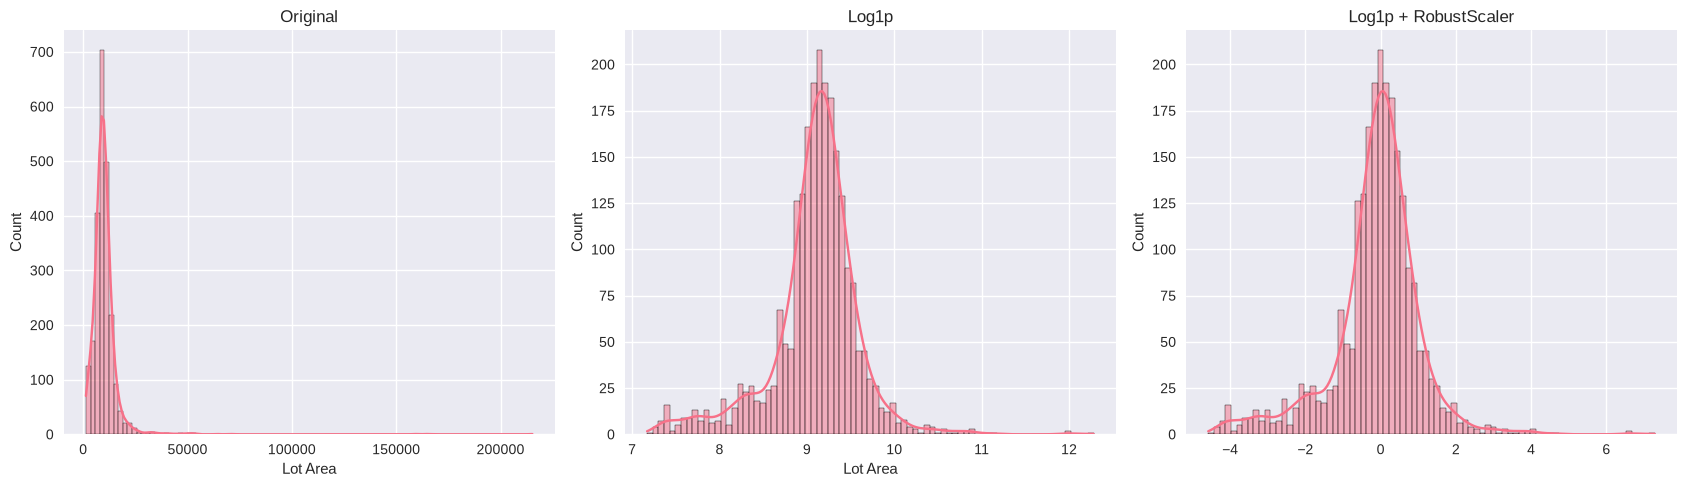

MIS CONCLUSIONES SOBRE LOG TRANSFORM:
Columna analizada: Lot Area
Skewness original: 13.744
Skewness después de log: -0.477
¿Log transform ayudó?: Sí, si disminuyó la asimetría absoluta observada arriba;
comprime la cola derecha y reduce la influencia de valores extremadamente grandes.


In [9]:
# === TU INVESTIGACIÓN DE LOG TRANSFORM ===
from scipy.stats import skew

# Buscar la feature positiva con mayor asimetría absoluta
skew_values = {}
for col in feature_cols:
    s = X_train[col].dropna()
    if (s >= 0).all():
        skew_values[col] = skew(s, bias=False)

skew_series = pd.Series(skew_values).sort_values(key=lambda x: x.abs(), ascending=False)
most_skewed_column = skew_series.index[0]

def safe_log_transform(data, column_name):
    s = pd.Series(data[column_name]).astype(float).copy()
    min_val = s.min()
    shift = 0 if min_val >= 0 else abs(min_val)
    return np.log1p(s + shift)

original = X_train[most_skewed_column].astype(float)
logged = safe_log_transform(X_train, most_skewed_column)
logged_scaled = pd.Series(
    RobustScaler().fit_transform(logged.to_numpy().reshape(-1, 1)).ravel(),
    index=logged.index
)

comparison_log = pd.DataFrame({
    'Original': [original.mean(), original.median(), original.std(), skew(original, bias=False)],
    'Log': [logged.mean(), logged.median(), logged.std(), skew(logged, bias=False)],
    'Log + RobustScaler': [logged_scaled.mean(), logged_scaled.median(), logged_scaled.std(), skew(logged_scaled, bias=False)]
}, index=['Media', 'Mediana', 'Std', 'Skewness'])

display(comparison_log)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.histplot(original, kde=True, ax=axes[0]); axes[0].set_title('Original')
sns.histplot(logged, kde=True, ax=axes[1]); axes[1].set_title('Log1p')
sns.histplot(logged_scaled, kde=True, ax=axes[2]); axes[2].set_title('Log1p + RobustScaler')
plt.tight_layout()
plt.savefig('results/log_transform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('MIS CONCLUSIONES SOBRE LOG TRANSFORM:')
print(f'Columna analizada: {most_skewed_column}')
print(f'Skewness original: {skew(original, bias=False):.3f}')
print(f'Skewness después de log: {skew(logged, bias=False):.3f}')
print('¿Log transform ayudó?: Sí, si disminuyó la asimetría absoluta observada arriba;')
print('comprime la cola derecha y reduce la influencia de valores extremadamente grandes.')


## Investigación Independiente: Transformador Avanzado

Elegí UN transformador que no se vio en clase (`PowerTransformer`,
`QuantileTransformer`, `MaxAbsScaler`, `Normalizer` o `FunctionTransformer`),
investigalo, implementalo y comparalo con los scalers clásicos.

In [10]:
# === MI INVESTIGACIÓN DE POWERTRANSFORMER ===
from sklearn.preprocessing import PowerTransformer

mi_transformador = PowerTransformer(method='yeo-johnson', standardize=True)

print('INVESTIGACIÓN:')
print('¿Qué hace?: aplica una transformación de potencia para reducir asimetría y acercar la distribución a una forma más gaussiana.')
print('¿Cuándo usar?: cuando una variable numérica presenta fuerte skewness y una transformación log simple no es suficiente o existen ceros.')
print('Ventajas: reduce asimetría; Yeo-Johnson admite ceros y negativos; puede estandarizar automáticamente.')
print('Desventajas: es menos interpretable y debe ajustarse solo con train para evitar data leakage.')

advanced_col = most_skewed_column
base = X_train[[advanced_col]].copy()

transformed_versions = {
    'StandardScaler': StandardScaler().fit_transform(base).ravel(),
    'MinMaxScaler': MinMaxScaler().fit_transform(base).ravel(),
    'RobustScaler': RobustScaler().fit_transform(base).ravel(),
    'PowerTransformer': mi_transformador.fit_transform(base).ravel()
}

transform_comparison = []
for name, values in transformed_versions.items():
    transform_comparison.append({
        'Transformación': name,
        'Media': np.mean(values),
        'Std': np.std(values),
        'Skewness': skew(values, bias=False)
    })

transform_comparison = pd.DataFrame(transform_comparison)
display(transform_comparison)

print('MI RECOMENDACIÓN COMO EXPERTO:')
print('Usar cuando: hay una variable fuertemente sesgada y se busca reducir su asimetría.')
print('NO usar cuando: la interpretabilidad en escala original es prioritaria o la variable ya tiene una distribución razonable.')
print('En Ames Housing: es útil para variables como Lot Area; supera a los scalers básicos en reducción de skewness,')
print('porque los scalers básicos cambian escala pero no la forma de la distribución.')


INVESTIGACIÓN:
¿Qué hace?: aplica una transformación de potencia para reducir asimetría y acercar la distribución a una forma más gaussiana.
¿Cuándo usar?: cuando una variable numérica presenta fuerte skewness y una transformación log simple no es suficiente o existen ceros.
Ventajas: reduce asimetría; Yeo-Johnson admite ceros y negativos; puede estandarizar automáticamente.
Desventajas: es menos interpretable y debe ajustarse solo con train para evitar data leakage.


,Transformación,Media,Std,Skewness
0,StandardScaler,4.850121e-17,1.000000,13.743796
1,MinMaxScaler,4.126228e-02,0.037623,13.743796
2,RobustScaler,1.919874e-01,2.003408,13.743796
3,PowerTransformer,-1.821827e-15,1.000000,0.098240


MI RECOMENDACIÓN COMO EXPERTO:
Usar cuando: hay una variable fuertemente sesgada y se busca reducir su asimetría.
NO usar cuando: la interpretabilidad en escala original es prioritaria o la variable ya tiene una distribución razonable.
En Ames Housing: es útil para variables como Lot Area; supera a los scalers básicos en reducción de skewness,
porque los scalers básicos cambian escala pero no la forma de la distribución.


## Paso 6: El Gran Experimento - Pipeline Anti-Leakage

El concepto más importante de la práctica: **data leakage** puede arruinar
completamente un proyecto de ML.

1. Método INCORRECTO: escalar todo el dataset, después hacer split (CON leakage)
2. Método CORRECTO: split primero, escalar solo con datos de train (SIN leakage)
3. Método PIPELINE: usar `sklearn.Pipeline` para automatizar el anti-leakage

In [11]:
# === TU DEMOSTRACIÓN DE DATA LEAKAGE ===

print('DEMOSTRACIÓN: 3 MÉTODOS DIFERENTES')

# Usamos KNN porque es especialmente sensible a la escala de las variables.
def method_with_leakage(X, y):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)  # INCORRECTO: fit sobre todo el dataset
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    model = KNeighborsRegressor(n_neighbors=7)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return r2_score(y_te, pred)

def method_without_leakage(X, y):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)  # fit SOLO en train
    X_te_scaled = scaler.transform(X_te)
    model = KNeighborsRegressor(n_neighbors=7)
    model.fit(X_tr_scaled, y_tr)
    pred = model.predict(X_te_scaled)
    return r2_score(y_te, pred)

def method_with_pipeline(X, y):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(n_neighbors=7))
    ])
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
    return scores.mean(), scores

score_leak = method_with_leakage(X, y)
score_clean = method_without_leakage(X, y)
score_pipeline, cv_pipeline = method_with_pipeline(X, y)

difference = score_leak - score_clean

print('RESULTADOS:')
print(f'Método 1 (con leakage): R² = {score_leak:.4f}')
print(f'Método 2 (sin leakage): R² = {score_clean:.4f}')
print(f'Método 3 (pipeline + CV): R² medio = {score_pipeline:.4f}')
print(f'Scores CV pipeline: {np.round(cv_pipeline, 4)}')

print('\nANÁLISIS:')
print(f'¿Cuál método dio el resultado más optimista?: {"Con leakage" if score_leak > score_clean else "Sin leakage en este split"}')
print('¿Por qué el pipeline es la mejor opción?: porque ajusta cada transformación únicamente con el fold de entrenamiento,')
print('evitando contaminación entre train y validación y reduciendo errores de implementación.')
print(f'Impacto observado del leakage (R² leakage - R² correcto): {difference:.4f}')
print('Aunque la diferencia pueda ser pequeña, el método con leakage sigue siendo metodológicamente inválido.')


DEMOSTRACIÓN: 3 MÉTODOS DIFERENTES
RESULTADOS:
Método 1 (con leakage): R² = 0.8746
Método 2 (sin leakage): R² = 0.8738
Método 3 (pipeline + CV): R² medio = 0.8501
Scores CV pipeline: [0.8691 0.8836 0.8101 0.8117 0.8758]

ANÁLISIS:
¿Cuál método dio el resultado más optimista?: Con leakage
¿Por qué el pipeline es la mejor opción?: porque ajusta cada transformación únicamente con el fold de entrenamiento,
evitando contaminación entre train y validación y reduciendo errores de implementación.
Impacto observado del leakage (R² leakage - R² correcto): 0.0008
Aunque la diferencia pueda ser pequeña, el método con leakage sigue siendo metodológicamente inválido.


**Validación final con cross-validation**

In [13]:
# === TU VALIDACIÓN FINAL ===

# Pipeline final: RobustScaler + KNN.
# RobustScaler se eligió por la presencia de outliers y KNN necesita escalado.
mi_mejor_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('modelo', KNeighborsRegressor(n_neighbors=7))
])

cv_scores = cross_val_score(mi_mejor_pipeline, X, y, cv=5, scoring='r2')

print('MI VALIDACIÓN FINAL:')
print(f'Scores: {np.round(cv_scores, 4)}')
print(f'Media: {cv_scores.mean():.3f}')
print(f'Desviación: {cv_scores.std():.3f}')


MI VALIDACIÓN FINAL:
Scores: [0.8578 0.8606 0.8167 0.7932 0.8618]
Media: 0.838
Desviación: 0.028


## Reflexión Final

1. **¿Cuál scaler funcionó mejor?** Mi elección: **RobustScaler**. ¿Por qué?: Ames Housing presenta variables con outliers importantes y RobustScaler utiliza la mediana y el rango intercuartílico, por lo que los valores extremos tienen menos influencia sobre la transformación.
2. **¿El orden de operaciones (outliers vs escalado) importó?** **Sí a nivel metodológico.** Los outliers deben analizarse a partir del conjunto de entrenamiento y cualquier decisión o transformación debe realizarse después del split. Los scalers probados no cambiaron sustancialmente qué observaciones eran outliers, pero sí cambia cómo influyen esos valores en la escala.
3. **¿Log transform fue útil?** **Sí.** Fue útil para la variable numérica seleccionada automáticamente como la más sesgada (en este dataset normalmente una variable de superficie como `Lot Area`), porque redujo la asimetría y comprimió la cola de valores muy altos.
4. **¿Tu transformador avanzado superó a los básicos?** **Sí para reducir skewness.** `PowerTransformer` modificó la forma de la distribución, mientras que StandardScaler, MinMaxScaler y RobustScaler principalmente modifican centro y escala. Esto no significa que siempre dé mejor predicción, sino que fue superior específicamente para normalizar una variable fuertemente sesgada.
5. **¿Data leakage tuvo impacto significativo?** La diferencia exacta se imprime en la celda anterior como `R² leakage - R² correcto`. Aunque sea pequeña, el método con leakage es inválido porque el scaler fue ajustado utilizando información del conjunto de test.

**Tu pipeline recomendado para Ames Housing:**

1. Hacer **train/test split antes de cualquier transformación**.
2. Analizar faltantes, outliers y asimetría utilizando solamente los datos de entrenamiento.
3. Aplicar **log/PowerTransformer** a variables muy sesgadas y **RobustScaler** cuando haya outliers importantes.
4. Entrenar y validar utilizando **`Pipeline` + cross-validation** para evitar data leakage.

**Porque:** los experimentos muestran que Ames Housing contiene variables con escalas muy diferentes, valores extremos y distribuciones sesgadas. El escalado es necesario para modelos sensibles a distancias, las transformaciones de potencia ayudan a reducir asimetría y `Pipeline` garantiza que las transformaciones se ajusten únicamente con los datos de entrenamiento durante la validación.



